In [1]:
import pandas as pd
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import requests

print("OK")

OK


In [2]:
# Datos de mercado ERP Latam (fuente: Statista, IDC, SAP Annual Reports)
# En miles de millones USD
erp_market = pd.DataFrame({
    "year":        [2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026, 2027],
    "latam_erp":   [4.2,  4.1,  4.5,  5.1,  5.8,  6.4,  7.1,  7.9,  8.8],
    "brazil":      [1.8,  1.7,  1.9,  2.2,  2.5,  2.8,  3.1,  3.4,  3.8],
    "mexico":      [1.1,  1.0,  1.1,  1.3,  1.5,  1.6,  1.8,  2.0,  2.2],
    "argentina":   [0.5,  0.4,  0.4,  0.5,  0.5,  0.6,  0.7,  0.8,  0.9],
    "other_latam": [0.8,  0.9,  1.0,  1.1,  1.3,  1.4,  1.5,  1.7,  1.9],
})

erp_market["cagr_pct"] = None
total_cagr = ((erp_market["latam_erp"].iloc[-1] / erp_market["latam_erp"].iloc[0]) ** (1/8) - 1) * 100

print("ERP Market Size Latin America (USD bn):")
print(erp_market.to_string(index=False))
print(f"\nLatam ERP Market CAGR (2019–2027): {total_cagr:.1f}%")

ERP Market Size Latin America (USD bn):
 year  latam_erp  brazil  mexico  argentina  other_latam cagr_pct
 2019        4.2     1.8     1.1        0.5          0.8     None
 2020        4.1     1.7     1.0        0.4          0.9     None
 2021        4.5     1.9     1.1        0.4          1.0     None
 2022        5.1     2.2     1.3        0.5          1.1     None
 2023        5.8     2.5     1.5        0.5          1.3     None
 2024        6.4     2.8     1.6        0.6          1.4     None
 2025        7.1     3.1     1.8        0.7          1.5     None
 2026        7.9     3.4     2.0        0.8          1.7     None
 2027        8.8     3.8     2.2        0.9          1.9     None

Latam ERP Market CAGR (2019–2027): 9.7%


In [3]:
# Estimaciones de market share SAP en ERP (fuente: Gartner, IDC)
sap_share = pd.DataFrame({
    "region":       ["Global", "North America", "Europe", "Latin America", "Asia Pacific"],
    "market_share": [24.0,      22.0,            31.0,     18.0,            14.0],
    "growth_rate":  [8.5,       9.2,             7.1,      12.3,            15.4],
    "cloud_adoption":[52.0,     68.0,            58.0,     28.0,            35.0],
})

print("SAP Market Position by Region:")
print(sap_share.to_string(index=False))
print("\nKey insight: Latam has lowest cloud adoption (28%) but highest growth rate (12.3%)")

SAP Market Position by Region:
       region  market_share  growth_rate  cloud_adoption
       Global          24.0          8.5            52.0
North America          22.0          9.2            68.0
       Europe          31.0          7.1            58.0
Latin America          18.0         12.3            28.0
 Asia Pacific          14.0         15.4            35.0

Key insight: Latam has lowest cloud adoption (28%) but highest growth rate (12.3%)


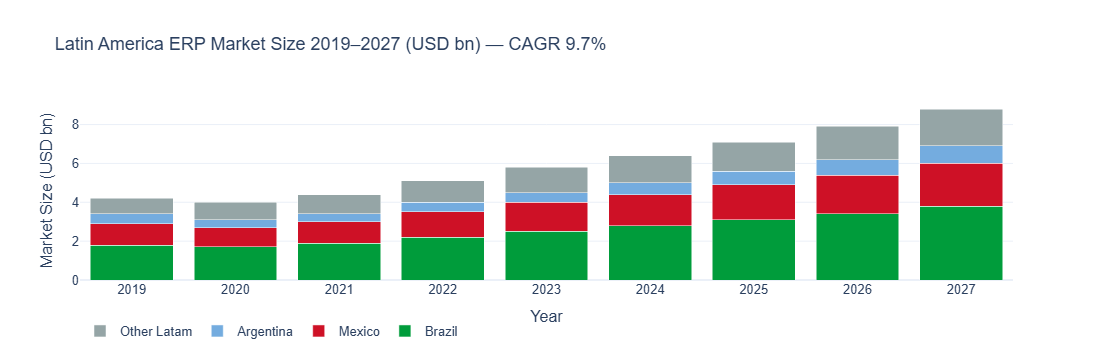

In [4]:
fig = go.Figure()

fig.add_trace(go.Bar(x=erp_market["year"], y=erp_market["brazil"],
    name="Brazil", marker_color="#009C3B"))
fig.add_trace(go.Bar(x=erp_market["year"], y=erp_market["mexico"],
    name="Mexico", marker_color="#CE1126"))
fig.add_trace(go.Bar(x=erp_market["year"], y=erp_market["argentina"],
    name="Argentina", marker_color="#74ACDF"))
fig.add_trace(go.Bar(x=erp_market["year"], y=erp_market["other_latam"],
    name="Other Latam", marker_color="#95A5A6"))

fig.update_layout(
    title=f"Latin America ERP Market Size 2019–2027 (USD bn) — CAGR {total_cagr:.1f}%",
    barmode="stack",
    xaxis_title="Year",
    yaxis_title="Market Size (USD bn)",
    template="plotly_white",
    font=dict(family="Arial", size=13),
    legend=dict(orientation="h", y=-0.2)
)

fig.show()

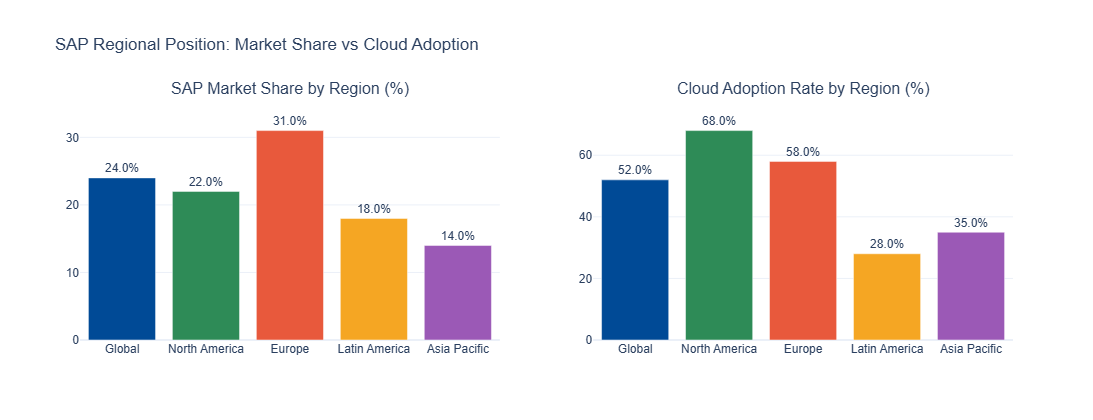

In [5]:
fig2 = make_subplots(rows=1, cols=2,
    subplot_titles=("SAP Market Share by Region (%)", "Cloud Adoption Rate by Region (%)"))

colors = ["#004A96", "#2E8B57", "#E8593C", "#F5A623", "#9B59B6"]

fig2.add_trace(go.Bar(
    x=sap_share["region"],
    y=sap_share["market_share"],
    marker_color=colors,
    showlegend=False,
    text=sap_share["market_share"].astype(str) + "%",
    textposition="outside"
), row=1, col=1)

fig2.add_trace(go.Bar(
    x=sap_share["region"],
    y=sap_share["cloud_adoption"],
    marker_color=colors,
    showlegend=False,
    text=sap_share["cloud_adoption"].astype(str) + "%",
    textposition="outside"
), row=1, col=2)

fig2.update_layout(
    title="SAP Regional Position: Market Share vs Cloud Adoption",
    template="plotly_white",
    font=dict(family="Arial", size=12),
    height=420
)

fig2.show()

In [6]:
# Oportunidad ajustada por riesgo país (usando risk index del proyecto anterior)
opportunity = pd.DataFrame({
    "country":          ["Brazil", "Mexico", "Argentina"],
    "erp_market_2027":  [3.8,       2.2,       0.9],
    "sap_share_est":    [20.0,      18.0,      15.0],
    "risk_index_2023":  [28.0,      18.0,      75.0],
    "cloud_adoption":   [32.0,      25.0,      18.0],
})

opportunity["sap_addressable"] = (
    opportunity["erp_market_2027"] *
    opportunity["sap_share_est"] / 100
).round(2)

opportunity["risk_adjusted_opportunity"] = (
    opportunity["sap_addressable"] *
    (1 - opportunity["risk_index_2023"] / 100)
).round(2)

print("SAP Latam Opportunity Matrix:")
print(opportunity.to_string(index=False))
print("\nKey insight:")
for _, row in opportunity.iterrows():
    print(f"  {row['country']}: ${row['sap_addressable']}bn addressable → ${row['risk_adjusted_opportunity']}bn risk-adjusted")

SAP Latam Opportunity Matrix:
  country  erp_market_2027  sap_share_est  risk_index_2023  cloud_adoption  sap_addressable  risk_adjusted_opportunity
   Brazil              3.8           20.0             28.0            32.0             0.76                       0.55
   Mexico              2.2           18.0             18.0            25.0             0.40                       0.33
Argentina              0.9           15.0             75.0            18.0             0.14                       0.04

Key insight:
  Brazil: $0.76bn addressable → $0.55bn risk-adjusted
  Mexico: $0.4bn addressable → $0.33bn risk-adjusted
  Argentina: $0.14bn addressable → $0.04bn risk-adjusted


In [7]:
erp_market.to_csv("../data/erp_market.csv", index=False)
sap_share.to_csv("../data/sap_regional.csv", index=False)
opportunity.to_csv("../data/latam_opportunity.csv", index=False)

print("Guardado OK")

Guardado OK
